[Allen-Cahn equation](https://en.wikipedia.org/wiki/Allen–Cahn_equation) 
$$
\begin{align}
& \large u_t - D u_{xx} + 5u^3 - 5u = 0, x \in [-1,1], t \in [0,1], \\
& \large u(x,0) = x^2 cos(\pi x), \\
&D = 0.001     \\
& \large u(-1,t) = u(1,t) = 1, \\
\end{align}
$$

In [ ]:
# 导入必要的库
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import scipy.io
import matplotlib.pyplot as plt
from collections import OrderedDict
import time
from torch.autograd import Variable

# 从sampling_PDE导入MMPDE采样类
from sampling_PDE import sampling_MMPDE

In [2]:
class LinearBlock(nn.Module):

    def __init__(self, in_nodes, out_nodes):
        super(LinearBlock, self).__init__()
        self.layer = nn.utils.weight_norm(nn.Linear(in_nodes, out_nodes), dim = 0)

    def forward(self, x):
        x = self.layer(x)
        x = torch.tanh(x) 
        return x

class PINN(nn.Module):

    def __init__(self, layer_list):
        super(PINN, self).__init__()
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.input_layer = nn.utils.weight_norm(nn.Linear(layer_list[0], layer_list[1]), dim = 0)
        self.hidden_layers = self._make_layer(layer_list[1:-1])
        self.output_layer = nn.Linear(layer_list[-2], layer_list[-1])
        
    def _make_layer(self, layer_list):
        layers = []
        for i in range(len(layer_list) - 1):
            block = LinearBlock(layer_list[i], layer_list[i + 1])
            layers.append(block)
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.input_layer(x)
        x = torch.tanh(x) 
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x

def weights_init(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_normal_(m.weight)

def create_pinn_for_mmpde(layer_list):
    model = PINN(layer_list)
    model.apply(weights_init)
    return model

In [3]:
def fwd_gradients(obj, x):
    dummy = torch.ones_like(obj)
    derivative = torch.autograd.grad(obj, x, dummy, create_graph= True)[0]
    return derivative

def ac_equation(u, tx):
    u_tx = fwd_gradients(u, tx)
    u_t = u_tx[:, 0:1]
    u_x = u_tx[:, 1:2]
    u_xx = fwd_gradients(u_x, tx)[:, 1:2]
    e = u_t -0.0001*u_xx + 5*u**3 - 5*u
    return e 

def resplot(x, t, t_data, x_data, Exact, u_pred):
    plt.figure(figsize=(10, 10))
    plt.subplot(2, 2, 1)
    plt.plot(x, Exact[:,0],'-')
    plt.plot(x, u_pred[:,0],'--')
    plt.legend(['Reference', 'Prediction'])
    plt.title("Initial condition ($t=0$)")
    
    plt.subplot(2, 2, 2)
    t_step = int(0.25*len(t))
    plt.plot(x, Exact[:,t_step],'-')
    plt.plot(x, u_pred[:,t_step],'--')
    plt.legend(['Reference', 'Prediction'])
    plt.title("$t=0.25$")
    
    plt.subplot(2, 2, 3)
    t_step = int(0.5*len(t))
    plt.plot(x, Exact[:,t_step],'-')
    plt.plot(x, u_pred[:,t_step],'--')
    plt.legend(['Reference', 'Prediction'])
    plt.title("$t=0.5$")
    
    plt.subplot(2, 2, 4)
    t_step = int(0.99*len(t))
    plt.plot(x, Exact[:,t_step],'-')
    plt.plot(x, u_pred[:,t_step],'--')
    plt.legend(['Reference', 'Prediction'])
    plt.title("$t=0.99$")
    plt.show()
    plt.close()

def ac_generator(num_t, num_x, typ='train'):
    N_f = num_t*num_x
    t = np.linspace(0, 1, num_t).reshape(-1,1) # T x 1
    x = np.linspace(-1, 1, num_x).reshape(-1,1) # N x 1
    T = t.shape[0]
    N = x.shape[0]
    T_star = np.tile(t, (1, N)).T  # N x T
    X_star = np.tile(x, (1, T))  # N x T
    
    # Initial condition and boundary condition
    u = np.zeros((N, T))  # N x T
    u[:,0:1] = (x**2)*np.cos(np.pi*x)
    u[0,:] = -np.ones(T) 
    u[-1,:] = u[0,:]
    
    t_data = T_star.flatten()[:, None]
    x_data = X_star.flatten()[:, None]
    u_data = u.flatten()[:, None]
    
    t_data_f = t_data.copy()
    x_data_f = x_data.copy()
    
    if typ == 'train':
        idx = np.random.choice(np.where((x_data == -1) | (x_data == 1))[0], num_t)
        t_data = t_data[idx]
        x_data = x_data[idx]
        u_data = u_data[idx]
        
        init_idx = np.random.choice(N-1, num_x-4, replace=False) + 1
        t_data = np.concatenate([t_data, np.ones((2,1)), np.zeros((num_x-4,1))], axis=0)
        x_data = np.concatenate([x_data, np.array([[-1], [1]]), x[init_idx]], axis=0)
        u_data = np.concatenate([u_data, -np.ones((2,1)), u[init_idx,0:1]], axis=0)
        
        return t_data, x_data, u_data, t_data_f, x_data_f
   
    else:
        return t_data_f, x_data_f

/root/miniconda3/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


Operation mode:  cuda:0


  0%|          | 0/5000 [00:00<?, ?it/s]

  1%|          | 29/5000 [00:00<00:17, 286.18it/s]

预训练 Epoch 0, Loss: 1.246017


...

预训练 Epoch 4000, Loss: 0.003461


 91%|█████████ | 4554/5000 [00:14<00:01, 291.05it/s]

预训练 Epoch 4500, Loss: 0.003039


100%|██████████| 5000/5000 [00:15<00:00, 316.81it/s]


预训练完成!
开始MMPDE自适应采样...
MMPDE_Adam Iter 100 Loss 17.26458 loss of equ 17.26458
MMPDE_Iter 10, Time: 0.8169
MMPDE_Adam Iter 200 Loss 5.6437716 loss of equ 5.6437716
MMPDE_Iter 10, Time: 0.7852
MMPDE_Adam Iter 300 Loss 3.309934 loss of equ 3.309934
MMPDE_Iter 10, Time: 0.8164
MMPDE_Adam Iter 400 Loss 1.6101153 loss of equ 1.6101153
MMPDE_Iter 10, Time: 0.8039
MMPDE_Adam Iter 500 Loss 0.66503954 loss of equ 0.66503954
MMPDE_Iter 10, Time: 0.7751
MMPDE_Adam Iter 600 Loss 0.51041424 loss of equ 0.51041424
MMPDE_Iter 10, Time: 0.7734
MMPDE_Adam Iter 700 Loss 0.46157303 loss of equ 0.46157303
MMPDE_Iter 10, Time: 0.7332
MMPDE_Adam Iter 800 Loss 0.42761564 loss of equ 0.42761564
MMPDE_Iter 10, Time: 0.7596
MMPDE_Adam Iter 900 Loss 0.39936262 loss of equ 0.39936262
MMPDE_Iter 10, Time: 0.8001
MMPDE_Adam Iter 1000 Loss 0.37161824 loss of equ 0.37161824
MMPDE_Iter 10, Time: 0.7496
MMPDE_Adam Iter 1100 Loss 0.34077814 loss of equ 0.34077814
MMPDE_Iter 10, Time: 0.7686
MMPDE_Adam Iter 1200 Loss 0.30

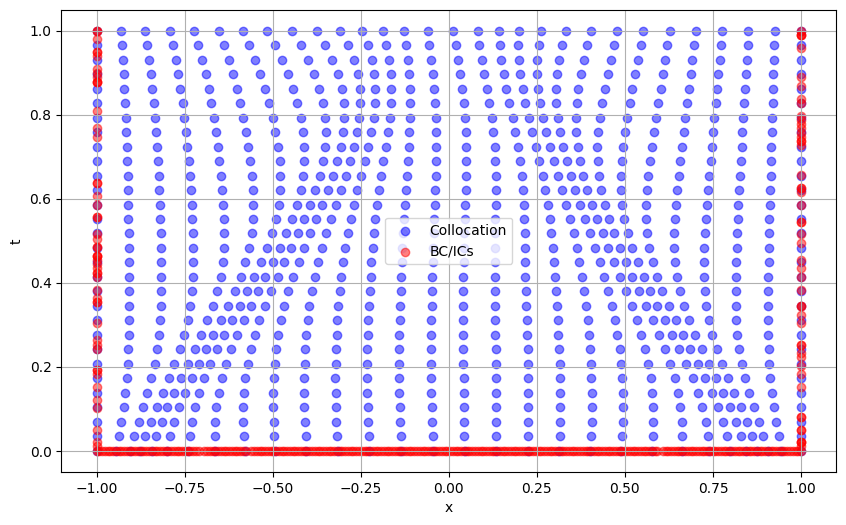

In [ ]:
# 设置默认参数
num_t = 100
num_x = 256
num_epochs = 200000
num_hidden = 4
num_nodes = 128
lr = 1e-3
nu = 0.1  # MMPDE参数

# 设置运行设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Operation mode: ", device)

# 定义Allen-Cahn方程的参数
lb = [0.0, -1.0]  # [t_min, x_min]
ub = [1.0, 1.0]   # [t_max, x_max]

# 生成训练数据
t_data, x_data, u_data, t_data_f, x_data_f = ac_generator(num_t, num_x)

variables = torch.FloatTensor(np.concatenate((t_data, x_data), 1)).to(device)
variables_f = torch.FloatTensor(np.concatenate((t_data_f, x_data_f), 1)).to(device)
variables_f.requires_grad = True
u_data = torch.FloatTensor(u_data).to(device)

# 步骤1: 创建并预训练一个PINN模型
pretrain_layers = [2, 20, 20, 1]
pretrain_model = create_pinn_for_mmpde(pretrain_layers).to(device)

# 预训练优化器
pretrain_optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=1e-3)

# 短暂预训练循环
for epoch in tqdm(range(5000)):  # 简短的预训练
    pretrain_optimizer.zero_grad()
    
    # 边界条件和初始条件损失
    u_pred = pretrain_model(variables)
    loss_data = torch.mean((u_pred - u_data) ** 2)
    
    # PDE损失
    u_pred_f = pretrain_model(variables_f)
    loss_pde = torch.mean(ac_equation(u_pred_f, variables_f) ** 2)
    
    # 总损失
    loss = loss_data + loss_pde
    
    loss.backward()
    pretrain_optimizer.step()
    
    if epoch % 500 == 0:
        print(f"预训练 Epoch {epoch}, Loss: {loss.item():.6f}")

print("预训练完成!")

# 创建train_U函数
def train_U(x):
    return pretrain_model(x)

# 步骤2: 生成均匀分布的初始采样点
num_samples_per_dim = 30  # 每个维度上的采样点数
t_uniform = torch.linspace(0, 1, num_samples_per_dim)
x_uniform = torch.linspace(-1, 1, num_samples_per_dim)

# 创建均匀网格
T_grid, X_grid = torch.meshgrid(t_uniform, x_uniform, indexing='ij')
t_init = T_grid.reshape(-1, 1)
x_init = X_grid.reshape(-1, 1)

# 合并为输入样本
X_f_init = torch.cat([t_init, x_init], dim=1).numpy()

# 步骤3: 使用预训练的PINN和MMPDE生成自适应采样点
mmpde_layers = [2, 20, 20, 1]  # MMPDE网络结构
adam_iter = 2000  # MMPDE的Adam迭代次数
lbfgs_iter = 500  # MMPDE的LBFGS迭代次数

# 创建MMPDE采样器
mmpde_sampler = sampling_MMPDE(
    X_f=X_f_init,
    u=train_U,  # 使用预训练模型的前向传播函数
    layers=mmpde_layers,
    lb=lb,
    ub=ub,
    nu=nu,
    AdamIter=adam_iter,
    LBFGSIter=lbfgs_iter
)

# 训练MMPDE并获取优化的采样点
print("开始MMPDE自适应采样...")
new_samples = mmpde_sampler.train()

# 提取优化后的采样点
t_colloc = new_samples[:, 0:1].clone().detach().requires_grad_(True)
x_colloc = new_samples[:, 1:2].clone().detach().requires_grad_(True)
variables_f_adaptive = torch.cat([t_colloc, x_colloc], dim=1).to(device)

# 可视化采样点
plt.figure(figsize=(10, 6))
plt.scatter(x_colloc.detach().cpu().numpy(), t_colloc.detach().cpu().numpy(), color='blue', alpha=0.5, label='Collocation')
plt.scatter(x_data, t_data, color='red', alpha=0.5, label='BC/ICs')
plt.xlabel('x')
plt.ylabel('t')
plt.legend()
plt.grid(True)
plt.show()

Operation mode:  cuda:0


/root/miniconda3/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")
  0%|          | 0/200000 [00:00<?, ?it/s]/root/miniconda3/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
  0%|          | 17/200000 [00:00<56:43, 58.76it/s]  

Train loss: 1.6091628074645996


  1%|          | 1031/200000 [00:06<20:47, 159.53it/s]

Train loss: 0.3609238266944885


...

Train loss: 6.199103097515035e-08


100%|█████████▉| 199021/200000 [21:18<00:06, 158.36it/s]

Train loss: 7.745461516606156e-08


100%|██████████| 200000/200000 [21:25<00:00, 155.62it/s]


[Best][Epoch: 199981] Train loss: 4.868009284564323e-08


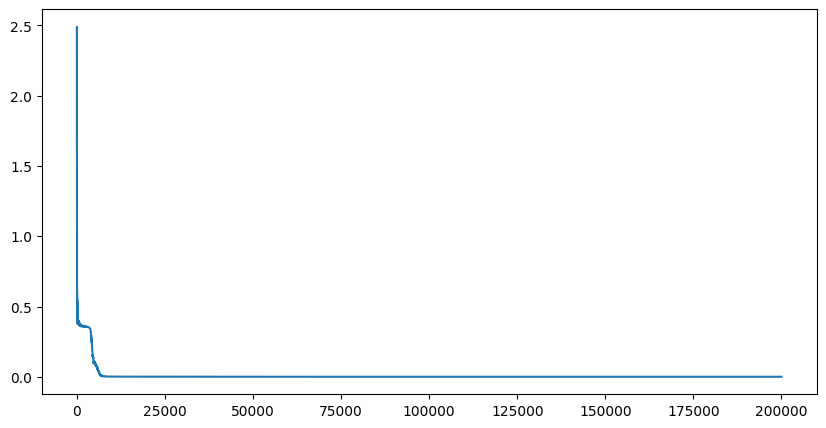

L2 Relative Error: 0.006312819203140823


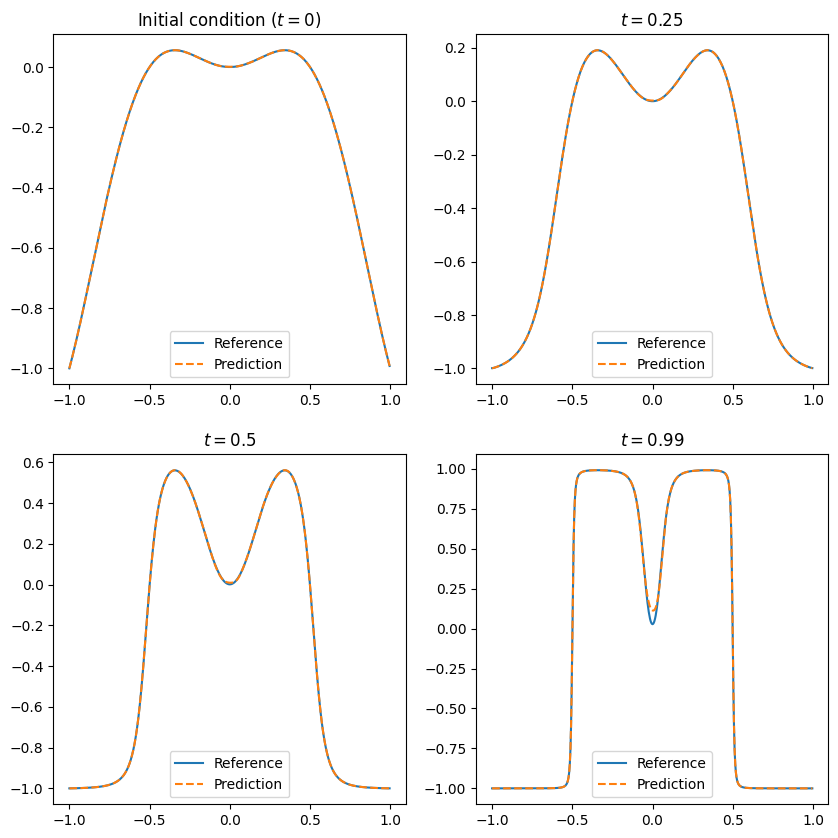

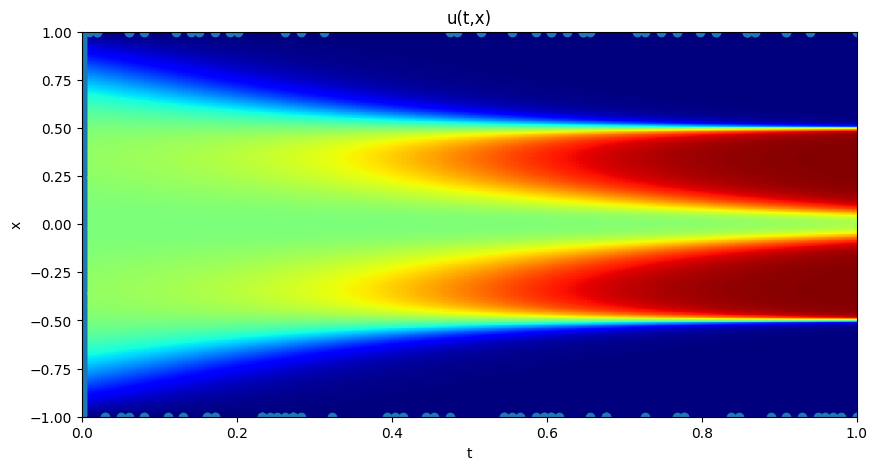

In [ ]:
# 步骤4: 使用MMPDE优化的采样点训练最终的PINN模型
final_layers = [2] + num_hidden * [num_nodes] + [1]
final_model = create_pinn_for_mmpde(final_layers).to(device)

# 训练优化器
optimizer = torch.optim.Adam(final_model.parameters(), betas=(0.999,0.999), lr=lr)
loss_graph = []
ls = 1e-3
bep = 0

for ep in tqdm(range(num_epochs)):
    optimizer.zero_grad()
    
    # 边界和初值条件
    u_hat = final_model(variables)
    loss_u = torch.mean((u_hat - u_data) ** 2)
    
    # 偏微分方程残差 - 使用自适应采样点
    u_hat_f = final_model(variables_f_adaptive)
    loss_f = torch.mean(ac_equation(u_hat_f, variables_f_adaptive) ** 2)
    
    # 总损失 - 需要权衡不同损失项
    loss = loss_f + 5.0 * loss_u  # 增加边界条件权重
    loss.backward() 
    optimizer.step()
    
    l = loss.item()
    loss_graph.append(l)
    if l < ls:
        ls = l
        bep = ep
        torch.save(final_model.state_dict(), './ac_1d_mmpde.pth')
        
    if ep % 1000 == 0:
        print(f"训练 Epoch {ep}, Loss: {l:.6f}, 边界损失: {loss_u.item():.6f}, PDE损失: {loss_f.item():.6f}")

# 输出训练结果和损失曲线
print(f"[最佳][Epoch: {bep}] 训练损失: {ls}") 
plt.figure(figsize=(10, 5))
plt.plot(loss_graph)
plt.yscale('log')
plt.title('训练损失曲线')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()